In [11]:
import heapq
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [12]:
def make_grid(rows, cols, obstacle_prob, seed):
    rng = random.Random(seed)
    grid = np.zeros((rows, cols), dtype=int)
    for r in range(rows):
        for c in range(cols):
            if rng.random() < obstacle_prob:
                grid[r][c] = 1
    grid[0][0] = 0
    grid[rows-1][cols-1] = 0
    return grid

In [13]:
grid = make_grid(10, 10, 0.25, 1)
print(grid)

[[0 0 0 0 0 0 0 0 1 1]
 [0 0 0 1 0 0 1 0 0 1]
 [1 0 0 0 1 0 1 1 0 0]
 [1 1 1 0 0 1 0 0 0 1]
 [0 0 1 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 1 0 0]
 [1 0 0 0 0 0 0 0 0 0]
 [0 1 1 0 0 0 0 1 0 0]
 [0 0 0 1 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 0 0]]


In [14]:
def show_grid(grid, start, goal, title="Grid"):
    plt.figure(figsize=(5, 5))
    plt.imshow(grid, cmap="Greys")
    plt.scatter(start[1], start[0], c="green", s=150, label="Start")
    plt.scatter(goal[1], goal[0], c="red", s=150, label="Goal")
    plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.02), ncol=2)
    plt.title(title)
    plt.xticks([])
    plt.yticks([])
    plt.show()

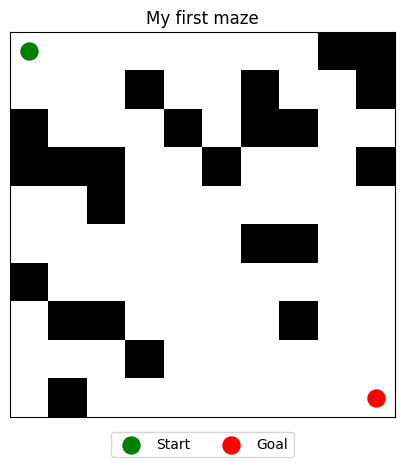

In [15]:
start = (0, 0)
goal = (9, 9)
show_grid(grid, start, goal, "My first maze")

In [16]:
def get_neighbors(grid, node):
    r, c = node
    rows, cols = grid.shape
    moves = [(-1, 0), (1, 0), (0, -1), (0, 1)]   # upar, neeche, left, right
    result = []
    for dr, dc in moves:
        nr, nc = r + dr, c + dc
        if 0 <= nr < rows and 0 <= nc < cols and grid[nr][nc] == 0:
            result.append((nr, nc))
    return result

In [17]:
print(get_neighbors(grid, (0, 0)))
print(get_neighbors(grid, (5, 5)))

[(1, 0), (0, 1)]
[(4, 5), (6, 5), (5, 4)]


In [18]:
def manhattan(a, b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1])

In [19]:
print(manhattan((0, 0), (9, 9)))

18


In [21]:
def reconstruct_path(came_from, current):
    path = [current]
    while current in came_from:
        current = came_from[current]
        path.append(current)
    path.reverse()
    return path

In [22]:
def dijkstra(grid, start, goal):
    t0 = time.perf_counter()
    heap = [(0, start)]
    dist = {start: 0}
    came_from = {}
    visited = set()
    expanded = 0
    while heap:
        d, node = heapq.heappop(heap)
        if node in visited:
            continue
        visited.add(node)
        expanded += 1
        if node == goal:
            path = reconstruct_path(came_from, goal)
            return {"path": path, "steps": len(path) - 1, "expanded": expanded,
                    "runtime_ms": (time.perf_counter() - t0) * 1000, "visited": visited}
        for nb in get_neighbors(grid, node):
            nd = d + 1
            if nd < dist.get(nb, float("inf")):
                dist[nb] = nd
                came_from[nb] = node
                heapq.heappush(heap, (nd, nb))
    return {"path": None, "steps": None, "expanded": expanded,
            "runtime_ms": (time.perf_counter() - t0) * 1000, "visited": visited}

In [23]:
def astar(grid, start, goal):
    t0 = time.perf_counter()
    heap = [(manhattan(start, goal), 0, start)]
    g_score = {start: 0}
    came_from = {}
    visited = set()
    expanded = 0
    while heap:
        f, g, node = heapq.heappop(heap)
        if node in visited:
            continue
        visited.add(node)
        expanded += 1
        if node == goal:
            path = reconstruct_path(came_from, goal)
            return {"path": path, "steps": len(path) - 1, "expanded": expanded,
                    "runtime_ms": (time.perf_counter() - t0) * 1000, "visited": visited}
        for nb in get_neighbors(grid, node):
            ng = g + 1
            if ng < g_score.get(nb, float("inf")):
                g_score[nb] = ng
                came_from[nb] = node
                heapq.heappush(heap, (ng + manhattan(nb, goal), ng, nb))
    return {"path": None, "steps": None, "expanded": expanded,
            "runtime_ms": (time.perf_counter() - t0) * 1000, "visited": visited}

In [24]:
res_d = dijkstra(grid, start, goal)
res_a = astar(grid, start, goal)

print("Dijkstra -> steps:", res_d["steps"], "| expanded:", res_d["expanded"], "| runtime(ms):", round(res_d["runtime_ms"], 3))
print("A*       -> steps:", res_a["steps"], "| expanded:", res_a["expanded"], "| runtime(ms):", round(res_a["runtime_ms"], 3))
print("Path:", res_a["path"])

Dijkstra -> steps: 18 | expanded: 75 | runtime(ms): 1.041
A*       -> steps: 18 | expanded: 61 | runtime(ms): 0.513
Path: [(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7), (1, 7), (1, 8), (2, 8), (3, 8), (4, 8), (4, 9), (5, 9), (6, 9), (7, 9), (8, 9), (9, 9)]


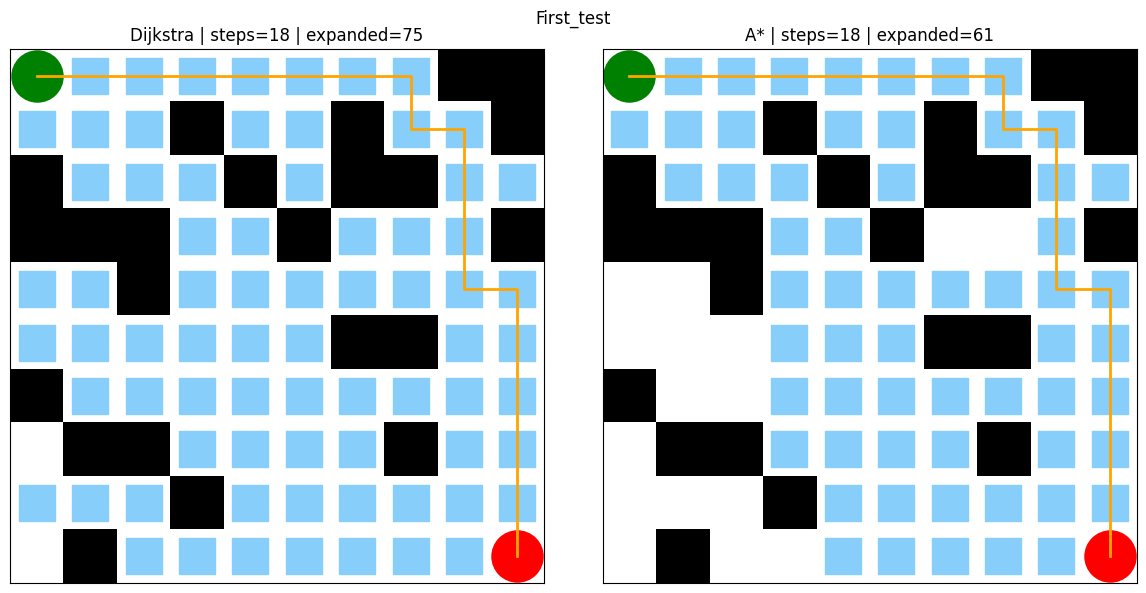

In [25]:
import os
os.makedirs("results", exist_ok=True)

def draw(ax, grid, start, goal, res, title):
    ax.imshow(grid, cmap="Greys")
    size = (260 / max(grid.shape)) ** 2
    if res["visited"]:
        vr = [n[0] for n in res["visited"]]
        vc = [n[1] for n in res["visited"]]
        ax.scatter(vc, vr, c="lightskyblue", s=size, marker="s")
    if res["path"]:
        ax.plot([p[1] for p in res["path"]], [p[0] for p in res["path"]], c="orange", linewidth=2)
    ax.scatter(start[1], start[0], c="green", s=size * 2)
    ax.scatter(goal[1], goal[0], c="red", s=size * 2)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])

def compare_plot(grid, start, goal, res_d, res_a, name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    draw(axes[0], grid, start, goal, res_d, f"Dijkstra | steps={res_d['steps']} | expanded={res_d['expanded']}")
    draw(axes[1], grid, start, goal, res_a, f"A* | steps={res_a['steps']} | expanded={res_a['expanded']}")
    fig.suptitle(name)
    plt.tight_layout()
    plt.savefig(f"results/{name}.png", dpi=120)
    plt.show()

compare_plot(grid, start, goal, res_d, res_a, "First_test")

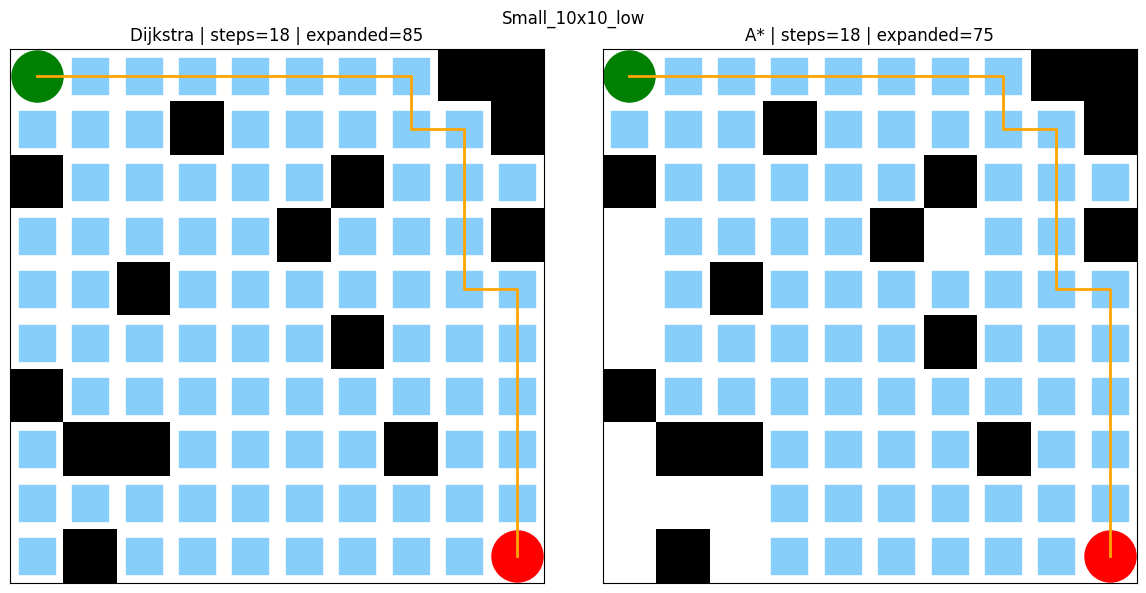

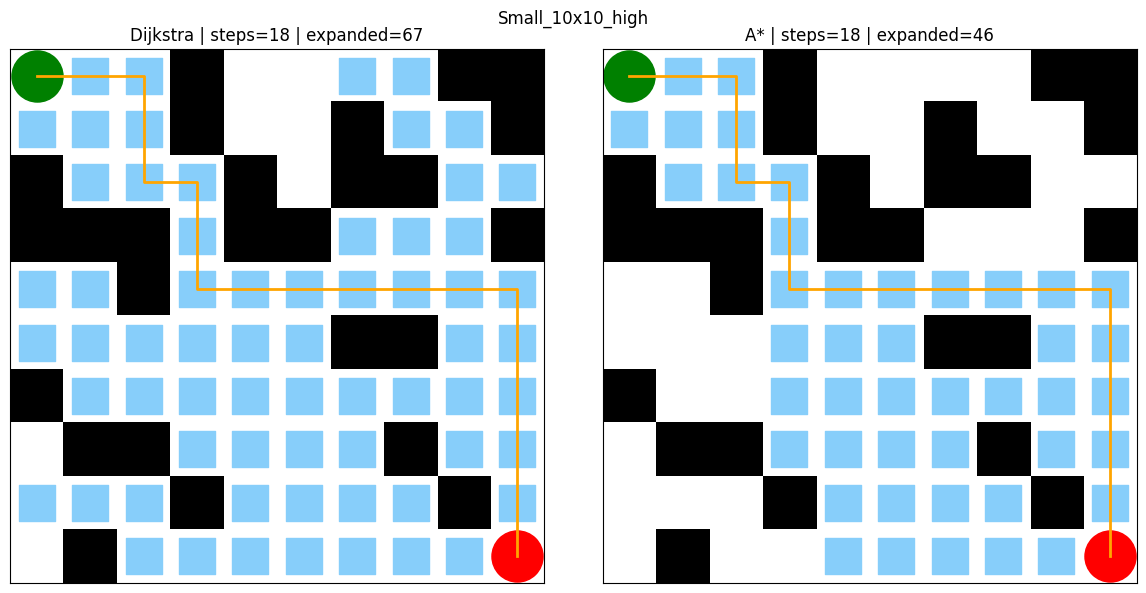

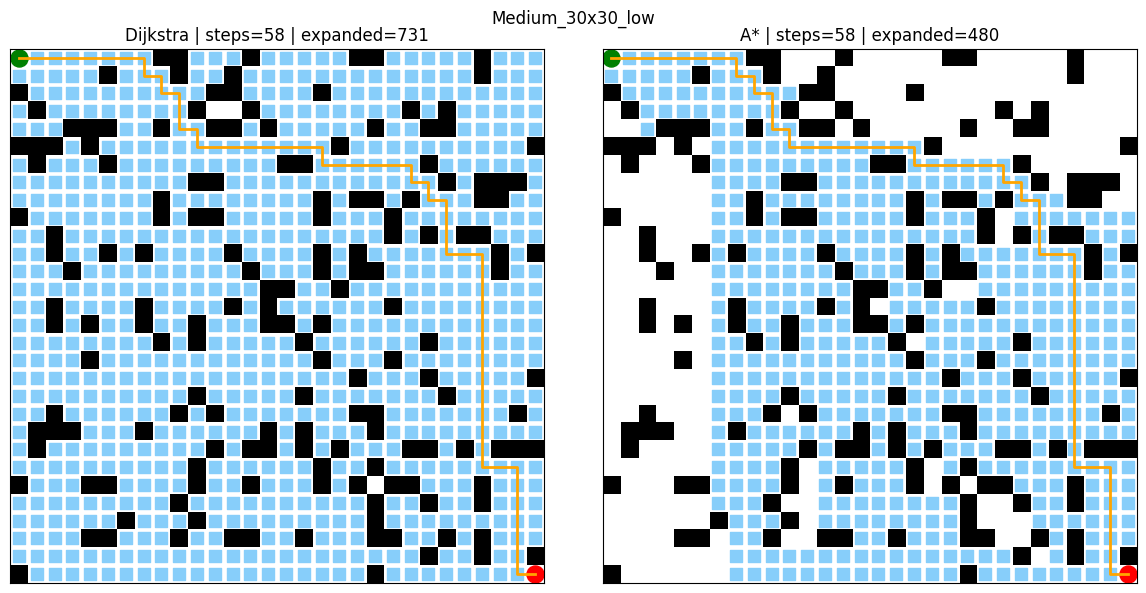

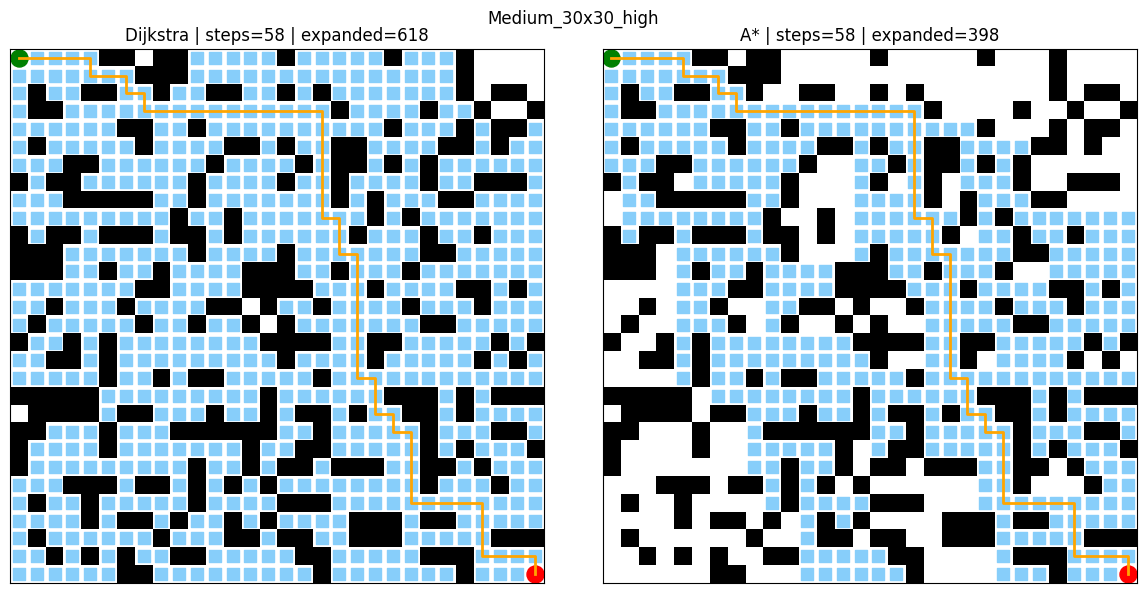

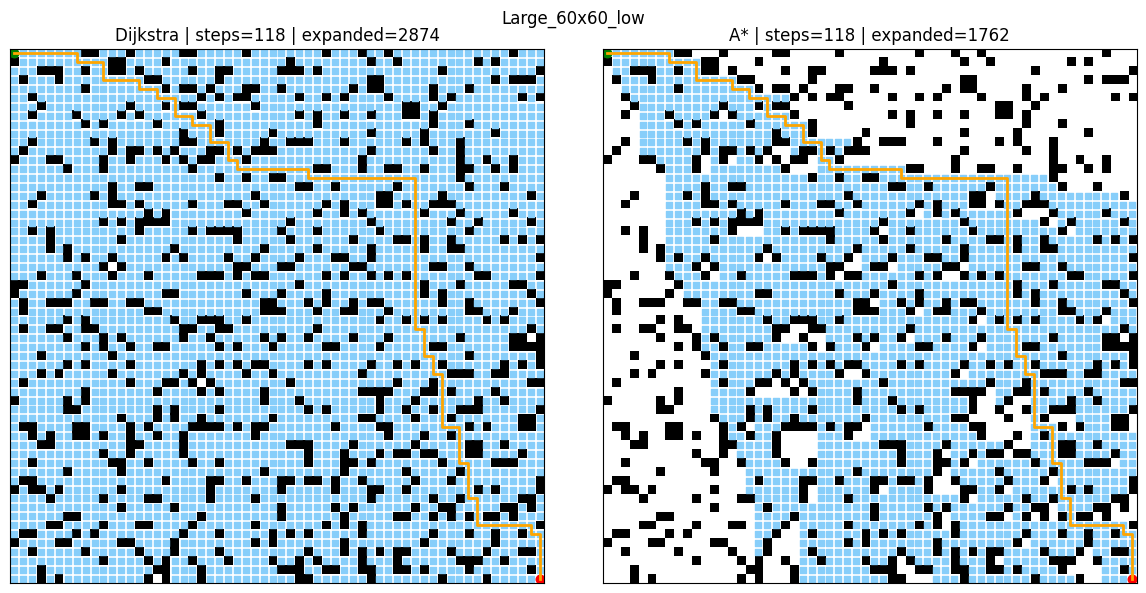

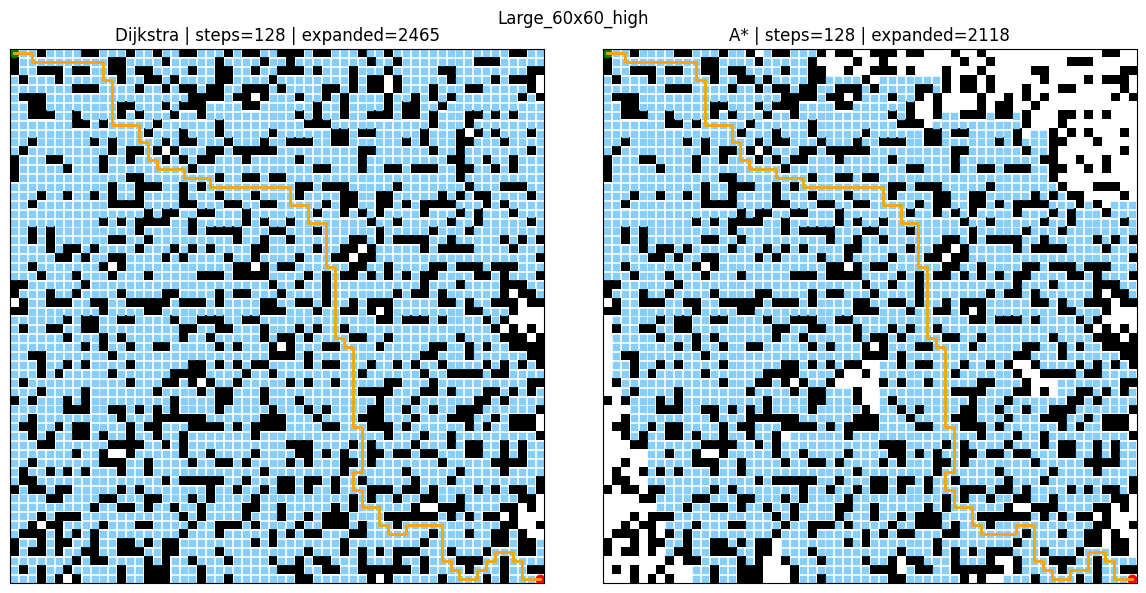

             case  grid  obstacles_% algorithm  path_found  steps  expanded_nodes  expanded_density_%  runtime_ms
  Small_10x10_low 10x10           20  Dijkstra        True     18              85               100.0       0.363
  Small_10x10_low 10x10           20        A*        True     18              75                88.2       0.322
 Small_10x10_high 10x10           30  Dijkstra        True     18              67                90.5       0.587
 Small_10x10_high 10x10           30        A*        True     18              46                62.2       0.454
 Medium_30x30_low 30x30           20  Dijkstra        True     58             731                99.6       5.539
 Medium_30x30_low 30x30           20        A*        True     58             480                65.4       4.120
Medium_30x30_high 30x30           30  Dijkstra        True     58             618                97.5       4.783
Medium_30x30_high 30x30           30        A*        True     58             398       

In [26]:
def run_algo(algo, grid, start, goal, runs=20):
    times = []
    for _ in range(runs):
        res = algo(grid, start, goal)
        times.append(res["runtime_ms"])
    res["runtime_ms"] = sum(times) / len(times)
    return res

test_cases = [
    ("Small_10x10_low",   10, 10, 0.20, 1),
    ("Small_10x10_high",  10, 10, 0.30, 1),
    ("Medium_30x30_low",  30, 30, 0.20, 1),
    ("Medium_30x30_high", 30, 30, 0.30, 3),
    ("Large_60x60_low",   60, 60, 0.20, 1),
    ("Large_60x60_high",  60, 60, 0.30, 1),
]

log = []
for name, r, c, p, seed in test_cases:
    g = make_grid(r, c, p, seed)
    st, gl = (0, 0), (r - 1, c - 1)
    free = int((g == 0).sum())
    res_d = run_algo(dijkstra, g, st, gl)
    res_a = run_algo(astar, g, st, gl)
    compare_plot(g, st, gl, res_d, res_a, name)
    for algo_name, res in [("Dijkstra", res_d), ("A*", res_a)]:
        log.append({
            "case": name,
            "grid": f"{r}x{c}",
            "obstacles_%": int(p * 100),
            "algorithm": algo_name,
            "path_found": res["path"] is not None,
            "steps": res["steps"],
            "expanded_nodes": res["expanded"],
            "expanded_density_%": round(res["expanded"] / free * 100, 1),
            "runtime_ms": round(res["runtime_ms"], 3),
        })

df = pd.DataFrame(log)
print(df.to_string(index=False))
df.to_csv("results/results_log.csv", index=False)

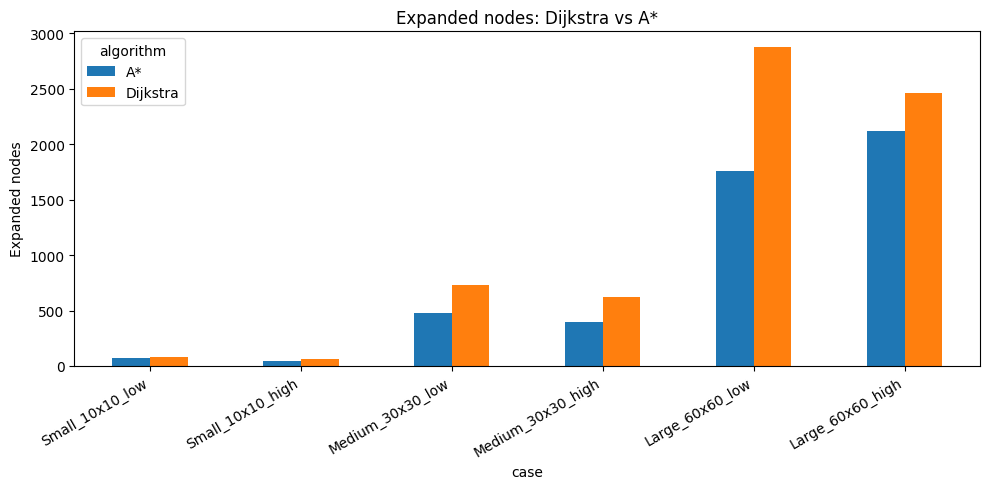

Small_10x10_low | same steps: True [18, 18]
Small_10x10_high | same steps: True [18, 18]
Medium_30x30_low | same steps: True [58, 58]
Medium_30x30_high | same steps: True [58, 58]
Large_60x60_low | same steps: True [118, 118]
Large_60x60_high | same steps: True [128, 128]


In [27]:
pivot = df.pivot(index="case", columns="algorithm", values="expanded_nodes")
pivot = pivot.loc[[t[0] for t in test_cases]]
pivot.plot(kind="bar", figsize=(10, 5))
plt.ylabel("Expanded nodes")
plt.title("Expanded nodes: Dijkstra vs A*")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("results/expanded_nodes_comparison.png", dpi=120)
plt.show()

for case, grp in df.groupby("case", sort=False):
    steps = grp["steps"].tolist()
    print(case, "| same steps:", steps[0] == steps[1], steps)

In [28]:
!zip -r results.zip results
from google.colab import files
files.download("results.zip")

  adding: results/ (stored 0%)
  adding: results/results_log.csv (deflated 58%)
  adding: results/Medium_30x30_high.png (deflated 23%)
  adding: results/expanded_nodes_comparison.png (deflated 17%)
  adding: results/First_test.png (deflated 26%)
  adding: results/Large_60x60_low.png (deflated 19%)
  adding: results/Small_10x10_low.png (deflated 25%)
  adding: results/Medium_30x30_low.png (deflated 25%)
  adding: results/Large_60x60_high.png (deflated 18%)
  adding: results/Small_10x10_high.png (deflated 25%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>